## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000015059B6B410> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
years = range(2009, 2024)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2009 | (1181870, 44)
Year: 2010 | (1181870, 44)
Year: 2011 | (1181870, 44)
Year: 2012 | (1185108, 44)
Year: 2013 | (1181870, 44)
Year: 2014 | (1181870, 44)
Year: 2015 | (1181870, 44)
Year: 2016 | (1185108, 44)
Year: 2017 | (1181870, 44)
Year: 2018 | (1181870, 44)
Year: 2019 | (1181870, 44)
Year: 2020 | (1185108, 44)


C:\Users\dimit\AppData\Local\Temp\ipykernel_188\1765925443.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)


Year: 2021 | (1181870, 44)
Year: 2022 | (1181870, 44)
Year: 2023 | (1181870, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

0

In [8]:
timeline_file.tail()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
17737759,24.067210,39.338070,3237,2023-12-27,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,14418.000000,14174.000000,0.000000,27,14319.967742,14113.483871,14247.464286,14057.535714,14397.774194,14156.225806,14567.766667,14205.733333,1.031560,240.055214,334.613615,1661.091750,2.000000,2,1
17737760,24.067210,39.338070,3237,2023-12-28,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,14418.000000,14168.000000,0.000000,28,14319.967742,14113.483871,14247.464286,14057.535714,14397.774194,14156.225806,14567.766667,14205.733333,1.031560,239.962482,331.180057,1661.091750,2.000000,2,1
17737761,24.067210,39.338070,3237,2023-12-29,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,14418.000000,14086.000000,0.031431,29,14319.967742,14113.483871,14247.464286,14057.535714,14397.774194,14156.225806,14567.766667,14205.733333,0.075283,173.391215,330.756156,1661.123181,2.000000,2,1
17737762,24.067210,39.338070,3237,2023-12-30,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,14418.000000,14086.000000,0.725881,30,14319.967742,14113.483871,14247.464286,14057.535714,14397.774194,14156.225806,14567.766667,14205.733333,0.801164,23.397546,331.482037,1661.849062,2.000000,2,1
17737763,24.067210,39.338070,3237,2023-12-31,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,14418.000000,14086.000000,0.006044,31,14319.967742,14113.483871,14247.464286,14057.535714,14397.774194,14156.225806,14567.766667,14205.733333,0.763356,1.836450,330.276635,1661.855106,2.000000,2,1


In [9]:
timeline_file.shape

(17737764, 44)

In [10]:
# wnv_file.head()

In [11]:
timeline_file['lst_day'] = timeline_file['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)
timeline_file['lst_night'] = timeline_file['lst_night'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [12]:
timeline_file['lst_day'] = timeline_file['lst_day'].astype(float)
timeline_file['lst_night'] = timeline_file['lst_night'].astype(float)

In [13]:
timeline_file['lst_night']

0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
               ...     
17737759   14174.000000
17737760   14168.000000
17737761   14086.000000
17737762   14086.000000
17737763   14086.000000
Name: lst_night, Length: 17737764, dtype: float64

In [14]:
# wnv_file.shape

In [15]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [16]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [17]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.155490,39.679430,0,2009-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.936785,1,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,13.936785,13.936785,13.936785,13.936785,2.000000,3,3
1,21.155490,39.679430,0,2009-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.526527,2,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,24.463312,24.463312,24.463312,24.463312,2.000000,3,3
2,21.155490,39.679430,0,2009-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.321799,3,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,182.785111,182.785111,182.785111,182.785111,2.000000,3,3
3,21.155490,39.679430,0,2009-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012812,4,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,183.797923,183.797923,183.797923,183.797923,2.000000,3,3
4,21.155490,39.679430,0,2009-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.438097,5,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,189.236020,189.236020,189.236020,189.236020,2.000000,3,3


In [18]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [19]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [20]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [21]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.155490,39.679430,0,2009-01-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.936785,1,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,13.936785,13.936785,13.936785,13.936785,2.000000,3,3,NaN,-4.745808,-5.169643,-6.814516,-2.975333,0.500000,0.866025
1,21.155490,39.679430,0,2009-01-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.526527,2,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,24.463312,24.463312,24.463312,24.463312,2.000000,3,3,NaN,-4.745808,-5.169643,-6.814516,-2.975333,0.500000,0.866025
2,21.155490,39.679430,0,2009-01-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.321799,3,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,182.785111,182.785111,182.785111,182.785111,2.000000,3,3,NaN,-4.745808,-5.169643,-6.814516,-2.975333,0.500000,0.866025
3,21.155490,39.679430,0,2009-01-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.012812,4,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,183.797923,183.797923,183.797923,183.797923,2.000000,3,3,NaN,-4.745808,-5.169643,-6.814516,-2.975333,0.500000,0.866025
4,21.155490,39.679430,0,2009-01-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.438097,5,-4.187000,-5.304615,-4.720714,-5.618571,-1.060968,-12.568065,4.579333,-10.530000,189.236020,189.236020,189.236020,189.236020,2.000000,3,3,NaN,-4.745808,-5.169643,-6.814516,-2.975333,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17737759,24.067210,39.338070,3237,2023-12-27,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,15.210000,10.330000,0.000000,27,13.249355,9.119677,11.799286,8.000714,14.805484,9.974516,18.205333,10.964667,1.031560,240.055214,334.613615,1661.091750,2.000000,2,1,12.770000,11.184516,9.900000,12.390000,14.585000,-0.000000,1.000000
17737760,24.067210,39.338070,3237,2023-12-28,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,15.210000,10.210000,0.000000,28,13.249355,9.119677,11.799286,8.000714,14.805484,9.974516,18.205333,10.964667,1.031560,239.962482,331.180057,1661.091750,2.000000,2,1,12.710000,11.184516,9.900000,12.390000,14.585000,-0.000000,1.000000
17737761,24.067210,39.338070,3237,2023-12-29,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,2023,12,0.449489,0.145443,-0.342933,-0.145443,0.384561,0.239775,-0.212432,-0.239775,0.192848,0.082109,0.249860,0.082109,15.210000,8.570000,0.031431,29,13.249355,9.119677,11.799286,8.000714,14.805484,9.974516,18.205333,10.964667,0.075283,173.391215,330.756156,1661.123181,2.00000

In [22]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [23]:
gc.collect()

0

In [24]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [25]:
del timeline_file
gc.collect()

0

In [26]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [27]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [28]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,-7.510000,-10.230000,-0.010000,-1.470000,495.120838
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,-10.710000,-11.150000,2.090000,-1.470000,214.435127
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,3.000000,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,-5.830000,-32.810000,2.370000,-6.910000,310.555581
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,4.000000,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,4.663111,45.037188,73.646778,139.893334,1160.004880,1.390000,-11.130000,5.690000,-7.530000,139.893334
4,0,2009-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,5.000000,0.488865,0.167587,-0.294683,-0.167587,0.407243,0.176672,-0.209849,-0.176672,0.066196,0.090496,0.076963,0.090496,16.501613,4.326129,10.413871,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,2.842737,57.986665,60.034040,82.011576,1248.129740,5.250000,-7.530000,24.630000,9.690000,88.124860


In [29]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,-7.510000,-10.230000,-0.010000,-1.470000,495.120838
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,-10.710000,-11.150000,2.090000,-1.470000,214.435127
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,3.000000,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,-5.830000,-32.810000,2.370000,-6.910000,310.555581
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,4.000000,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,4.663111,45.037188,73.646778,139.893334,1160.004880,1.390000,-11.130000,5.690000,-7.530000,139.893334
4,0,2009-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2.000000,3.000000,3.000000,2009.000000,5.000000,0.488865,0.167587,-0.294683,-0.167587,0.407243,0.176672,-0.209849,-0.176672,0.066196,0.090496,0.076963,0.090496,16.501613,4.326129,10.413871,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,2.842737,57.986665,60.034040,82.011576,1248.129740,5.250000,-7.530000,24.630000,9.690000,88.124860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582835,3237,2023-08,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.000000,2.000000,1.000000,2023.000000,8.000000,0.366341,-0.025527,-0.355375,0.025527,0.331655,0.046488,-0.257083,-0.046488,0.145332,0.089578,0.216705,0.089578,31.867419,24.166774,28.017097,13.249355,11.799286,14.805484,18.205333,9.119677,8.000714,9.974516,10.964667,11.184516,9.900000,12.390000,14.585000,0.119621,0.000000,0.000000,3.708236,877.003746,27.550000,21.490000,37.050000,27.230000,3.708236
582836,3237,2023-09,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2.000000,2.000000,1.000000,2023.000000,9.000000,0.363594,-0.011684,-0.349679,0.011684

In [30]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [31]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [32]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [33]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,495.120838,-10.230000,-0.010000
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,214.435127,-11.150000,2.090000
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,3,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,310.555581,-32.810000,2.370000
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,4,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,4.663111,45.037188,73.646778,139.893334,1160.004880,139.893334,-11.130000,5.690000
4,0,2009-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,5,0.488865,0.167587,-0.294683,-0.167587,0.407243,0.176672,-0.209849,-0.176672,0.066196,0.090496,0.076963,0.090496,16.501613,4.326129,10.413871,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,2.842737,57.986665,60.034040,82.011576,1248.129740,88.124860,-7.530000,24.630000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582835,3237,2023-08,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2023,8,0.366341,-0.025527,-0.355375,0.025527,0.331655,0.046488,-0.257083,-0.046488,0.145332,0.089578,0.216705,0.089578,31.867419,24.166774,28.017097,13.249355,11.799286,14.805484,18.205333,9.119677,8.000714,9.974516,10.964667,11.184516,9.900000,12.390000,14.585000,0.119621,0.000000,0.000000,3.708236,877.003746,3.708236,21.490000,37.050000
582836,3237,2023-09,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,39.338070,2,2,1,2023,9,0.363594,-0.011684,-0.349679,0.011684,0.334278,0.058770,-0.257081,-0.058770,0.138943,0.079810,0.204712,0.079810,26.808000,20.546000,23.677000,13.249355,11.799286,14.805484,18.205333,9.119677,8.000714,9.974516,10.964667,11.184516,9.900000,12.390000,14.585000,11.056594,10.646146,11.579994,331.697819,1208.701565,331.697819,18.490000,31.590000
582837,3237,2023-10,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",αλοννησου,24.067210,3

### Add Geomorphological and Land Cover/Use

In [34]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [35]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [36]:
dataset_locations

,x,y
0,21.155490,39.679430
1,21.155490,39.679430
2,21.178600,39.625530
3,21.178600,39.625530
4,21.178600,39.643500
...,...,...
5130,23.905450,39.194330
5131,23.905450,39.212300
5132,23.905450,39.212300
5133,23.928560,39.230270


In [37]:
dataset_locations_per_year

,x,y,year
0,21.155490,39.679430,2009
1,21.155490,39.679430,2009
2,21.155490,39.679430,2010
3,21.155490,39.679430,2010
4,21.155490,39.679430,2011
...,...,...,...
67876,24.067210,39.338070,2019
67877,24.067210,39.338070,2020
67878,24.067210,39.338070,2021
67879,24.067210,39.338070,2022


In [38]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [39]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 5.484765420413403e-06
Max distance: 0.00044491104150597155


In [40]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_188\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [41]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
2,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
3,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
4,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
...,...,...,...,...,...,...,...,...,...,...
5130,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
5131,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
5132,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
5133,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [42]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [43]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [44]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [45]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
1,21.155490,39.679430,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379
2,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
3,21.178600,39.625530,22359.174513,1561.273622,32,254.179204,1681.751389,176.989248,0.000000,3.146997
4,21.178600,39.643500,22073.181364,437.397275,16,177.777467,1397.093454,160.244280,0.000000,6.601146
...,...,...,...,...,...,...,...,...,...,...
5130,23.905450,39.194330,1605.267341,48889.605025,12,212.128782,260.256967,168.750910,0.000000,3.803597
5131,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
5132,23.905450,39.212300,1130.893787,48888.954874,13,257.572131,379.420309,185.095132,0.000000,1.061765
5133,23.928560,39.230270,1155.267987,50961.680408,14,180.778128,269.381324,170.808592,0.000000,1.553148


In [46]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [47]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [48]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [49]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [50]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [51]:
landcover_2023 = landcover_2022

In [52]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2010
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2011
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2012
Min distance: 5.484765420413403e-06
Max distance: 0.00044491104150597155
Year: 2013
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2014
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2015
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2016
Min distance: 5.484765420413403e-06
Max distance: 0.00044491104150597155
Year: 2017
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2018
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2019
Min distance: 5.484765537124604e-06
Max distance: 0.00044491104150597155
Year: 2020
Min distance: 5.484765420413403e-06
Max distance: 0.0004449110415

In [53]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [54]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.155490,39.679430,2009,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
1,21.155490,39.679430,2009,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
2,21.178600,39.625530,2009,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
3,21.178600,39.625530,2009,31,98,36,98.000000,30,98,12,12,1,6,7,2,0
4,21.178600,39.643500,2009,22,85,20,85.000000,20,85,9,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67876,23.905450,39.194330,2023,21,82,20,82.000000,20,82,8,8,4,2,2,2,0
67877,23.905450,39.212300,2023,21,92,20,92.000000,20,92,8,8,4,1,1,2,0
67878,23.905450,39.212300,2023,21,92,20,92.000000,20,92,8,8,4,1,1,2,0
67879,23.928560,39.230270,2023,21,78,20,78.000000,20,78,8,8,4,1,1,2,0


In [55]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [56]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [57]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [58]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [59]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2009,1,495.120838,-10.230000,-0.010000
1,0,2009,2,214.435127,-11.150000,2.090000
2,0,2009,3,310.555581,-32.810000,2.370000
3,0,2009,4,139.893334,-11.130000,5.690000
4,0,2009,5,88.124860,-7.530000,24.630000
5,0,2009,6,163.390056,6.390000,32.390000
6,0,2009,7,83.230116,8.910000,37.610000
7,0,2009,8,84.097374,10.210000,32.750000
8,0,2009,9,56.833128,6.510000,29.190000
9,0,2009,10,360.727996,1.270000,23.790000


In [60]:
# wnv_file.head(5)

In [61]:
# wnv_file

In [62]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582840 entries, 0 to 582839
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          582840 non-null  int64    
 1   dt_placement         582840 non-null  period[M]
 2   NUTS1_ID             582840 non-null  object   
 3   NUTS1_NAME           582840 non-null  object   
 4   NUTS2_ID             582840 non-null  object   
 5   NUTS2_NAME           582840 non-null  object   
 6   NUTS3_ID             582840 non-null  object   
 7   NUTS3_NAME           582840 non-null  object   
 8   LAU1_NAME            582840 non-null  object   
 9   x                    582840 non-null  float64  
 10  y                    582840 non-null  float64  
 11  MOUNT_TYPE           582840 non-null  int32    
 12  URBN_TYPE            582840 non-null  int32    
 13  COAST_TYPE           582840 non-null  int32    
 14  year                 582840 non-null

In [63]:
# wnv_file.info()

In [64]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [65]:
# wnv_file.info()

In [66]:
# wnv_file

In [67]:
# wnv_file['cases'].value_counts()

In [68]:
# wnv_file.cases.sum()

In [69]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [70]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,495.120838,-10.230000,-0.010000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,214.435127,-11.150000,2.090000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,3,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,310.555581,-32.810000,2.370000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,4,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,4.663111,45.037188,73.646778,139.893334,1160.004880,139.893334,-11.130000,5.690000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
4,0,2009-05,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,5,0.488865,0.167587,-0.294683,-0.167587,0.407243,0.176672,-0.209849,-0.176672,0.066196,0.090496,0.076963,0.090496,16.501613,4.326129,10.413871,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,2.842737,57.986665,60.034040,82.011576,1248.129740,88.124860,-7.530000,24.630000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582835,3237,2023-08,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL613,"μαγνησια, 

In [71]:
# merged = fillna(merged,{'cases': 0})

In [72]:
# merged['cases'].value_counts()

In [73]:
# merged.cases.sum()

In [74]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

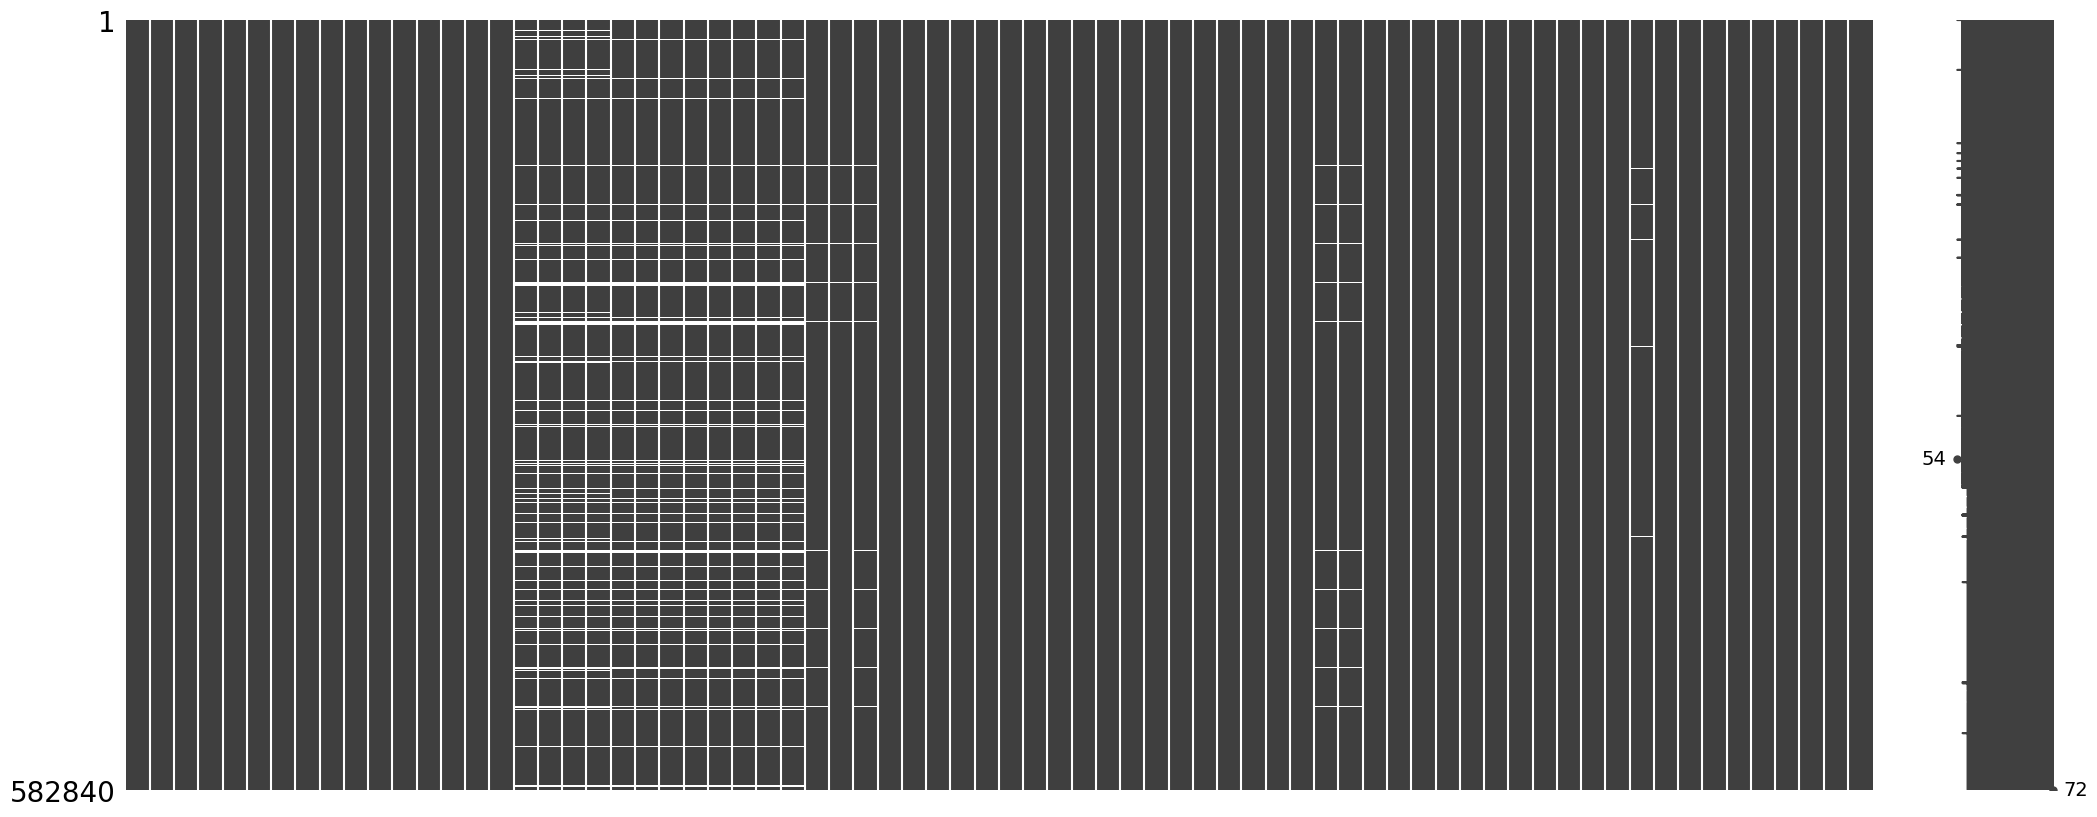

In [75]:
missingno.matrix(merged)

In [76]:
gc.collect()

0

In [77]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

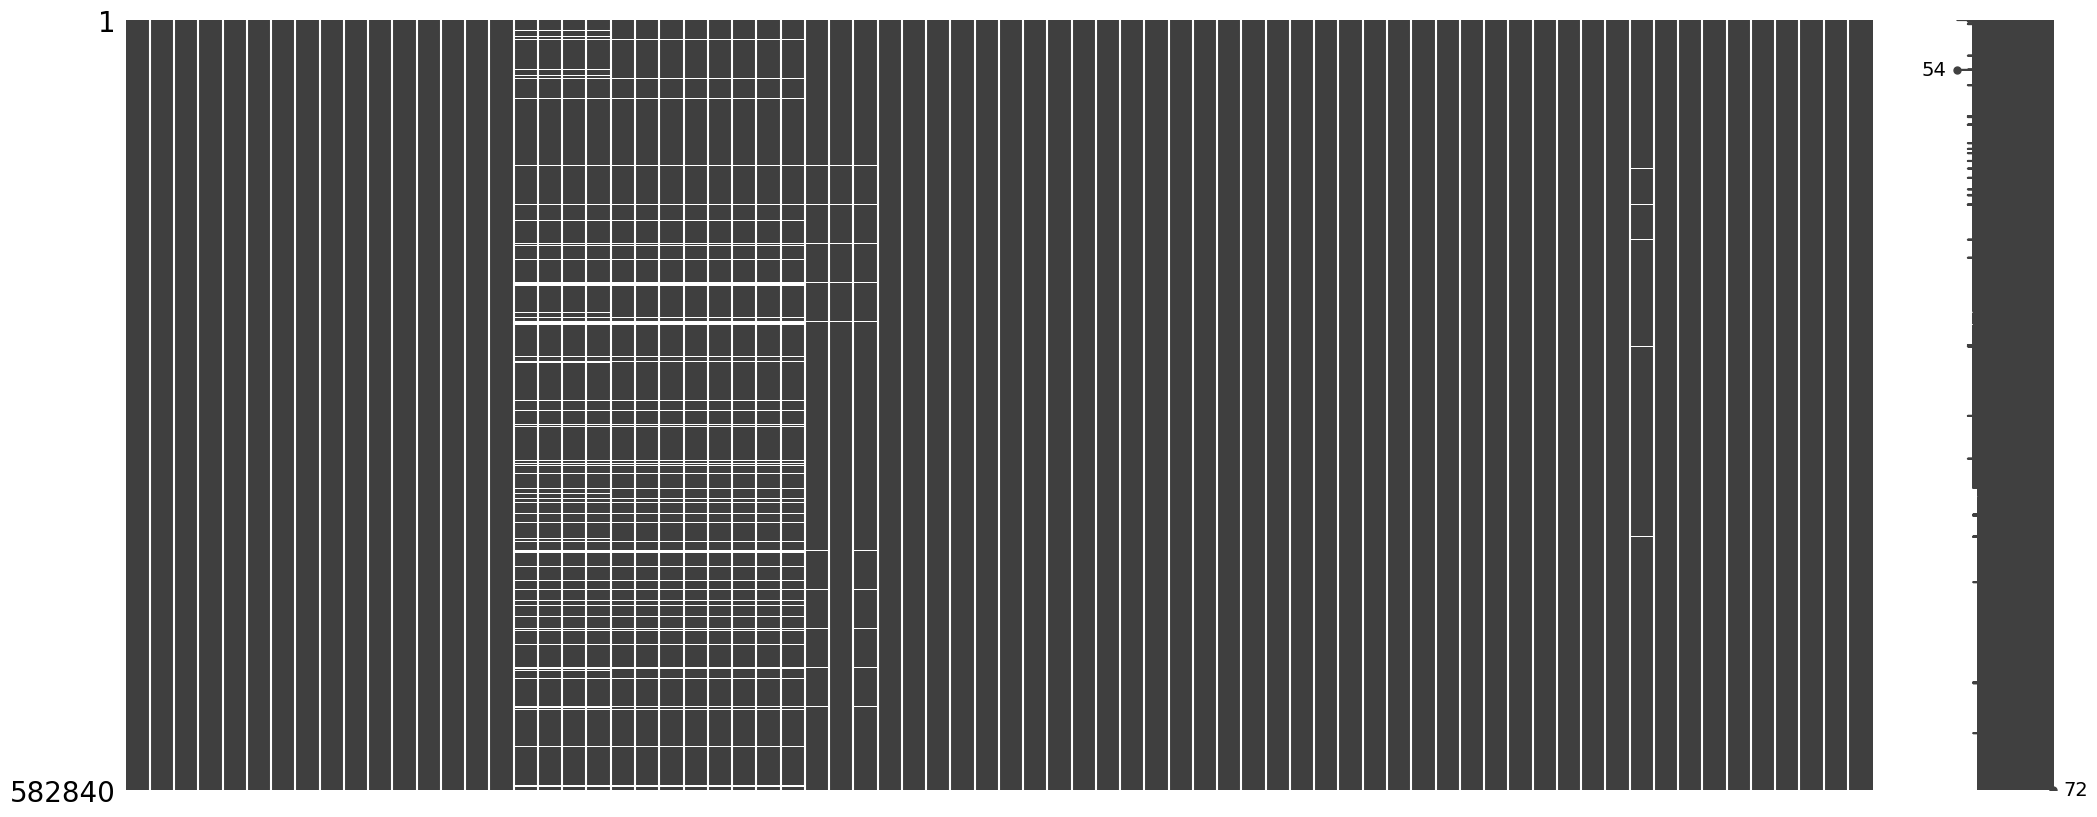

In [78]:
missingno.matrix(merged)

In [79]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])

In [80]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3235, 3236, 3237], dtype=int64)

In [81]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [82]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2009,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000
1,1,2009,8.500000,19.000000,35.849057,1059.802726,36.000000,-17.000000,53.000000,1.666667,20.166667,20.166667,-5.833333,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000
2,2,2009,10.750000,17.833333,37.152778,896.330905,37.000000,-11.000000,48.000000,4.500000,20.833333,20.833333,-1.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000
3,3,2009,8.500000,18.166667,40.370370,977.241014,35.000000,-10.000000,45.000000,1.500000,19.833333,19.833333,-3.500000,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,223.000000,1019.000000
4,4,2009,10.125000,18.916667,41.123188,913.316882,36.000000,-10.000000,46.000000,2.833333,20.666667,20.666667,-1.666667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,223.000000,1019.000000
5,5,2009,9.583333,21.166667,42.333333,1026.873749,37.000000,-13.000000,50.000000,2.166667,20.833333,20.833333,-4.833333,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,223.000000,1019.000000
6,6,2009,9.041667,19.583333,36.265432,972.919303,36.000000,-18.000000,54.000000,3.000000,20.166667,20.166667,-3.666667,2622.000000,461.000000,63.000000,64.690587,1207.000000,216.000000,216.000000,937.000000
7,7,2009,9.166667,18.500000,36.274510,908.628670,34.000000,-17.000000,51.000000,3.000000,19.333333,19.333333,-2.666667,2622.000000,461.000000,63.000000,64.690587,1207.000000,216.000000,216.000000,937.000000
8,8,2009,10.541667,16.916667,41.260163,791.850059,34.000000,-7.000000,41.000000,4.000000,20.000000,20.500000,1.000000,2622.000000,461.000000,63.000000,64.690587,1207.000000,216.000000,301.000000,937.000000
9,9,2009,9.791667,17.250000,38.333333,905.402556,35.000000,-10.000000,45.000000,3.000000,20.000000,20.166667,-2.166667,2622.000000,461.000000,63.000000,64.690587,1207.000000,216.000000,301.000000,937.000000


In [83]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [84]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
96,0,2017-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2017,1,0.511348,0.094143,-0.505720,-0.094143,0.541273,0.233714,-0.466527,-0.233714,0.097932,0.167094,0.065924,0.167094,-6.297097,-3.650000,-4.973548,-6.297097,-0.759286,6.835806,15.912667,-3.650000,0.787143,1.475806,2.012000,-4.973548,0.013929,4.155806,8.962333,8.588974,72.528639,148.749361,266.252725,266.258185,266.258185,-16.690000,-2.670000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,96,36,92.000000,30,96,12,12,1,6,7,2,0,9.916667,21.166667,40.705128,965.738844,36.000000,-16.000000,52.000000,-1.000000,16.333333,21.000000,-3.333333,1906.000000,495.000000,14.000000,93.819631,1164.000000,136.000000,176.000000,797.000000
97,0,2017-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2017,2,0.103714,0.616766,-0.140203,-0.616766,0.145503,0.723925,-0.153906,-0.723925,0.134722,0.111105,0.102393,0.111105,-0.759286,0.787143,1.321429,-6.297097,-0.759286,6.835806,15.912667,-3.650000,0.787143,1.475806,2.012000,-4.973548,0.013929,4.155806,8.962333,4.597506,45.685285,80.403046,128.730165,394.988350,128.730165,-3.490000,3.970000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,96,36,92.000000,30,96,12,12,1,6,7,2,0,9.916667,21.166667,40.705128,965.738844,36.000000,-16.000000,52.000000,-1.000000,16.333333,21.000000,-3.333333,1906.000000,495.000000,14.000000,93.819631,1164.000000,136.000000,176.000000,797.000000
98,0,2017-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2017,3,0.111170,0.591415,-0.140788,-0.591415,0.154305,0.697535,-0.157208,-0.697535,0.136588,0.110340,0.105372,0.110340,6.835806,1.475806,4.155806,-6.297097,-0.759286,6.835806,15.912667,-3.650000,0.787143,1.475806,2.012000,-4.973548,0.013929,4.155806,8.962333,3.760153,2.977481,23.615661,114.963480,511.553101,116.564751,-1.130000,17.970000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,96,36,92.000000,30,96,12,12,1,6,7,2,0,9.916667,21.166667,40.705128,965.738844,36.000000,-16.000000,52.000000,-1.000000,16.333333,21.000000,-3.333333,1906.000000,495.000000,14.000000,93.819631,1164.000000,136.000000,176.000000,797.000000
99,0,2017-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2017,4,0.367847,0.100927,-0.358295,-0.100927,0.399148,0.204380,-0.361570,-0.204380,0.152782,0.097540,0.121815,0.097540,15.912667,2.012000,8.962333,-6.297097,-0.759286,6.835806,15.912667,-3.650000,0.787143,1.475806,2.012000,-4.973548,0.013929,4.155806,8.962333,2.566085,3.844025,19.474104,76.982546,588.535647,76.982546,-1.350000,21.950000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,96,36,92.000000,30,96,12,12,1,6,7,2,0,9.916667,21.166667,40.705128,965.738844,36.000000,-16.000000,52.000000,-1.000000,16.333333,21.000000,-3.333333,1906.000000,495.000000,14.000000,93.81963

In [85]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [86]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [87]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [88]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [89]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

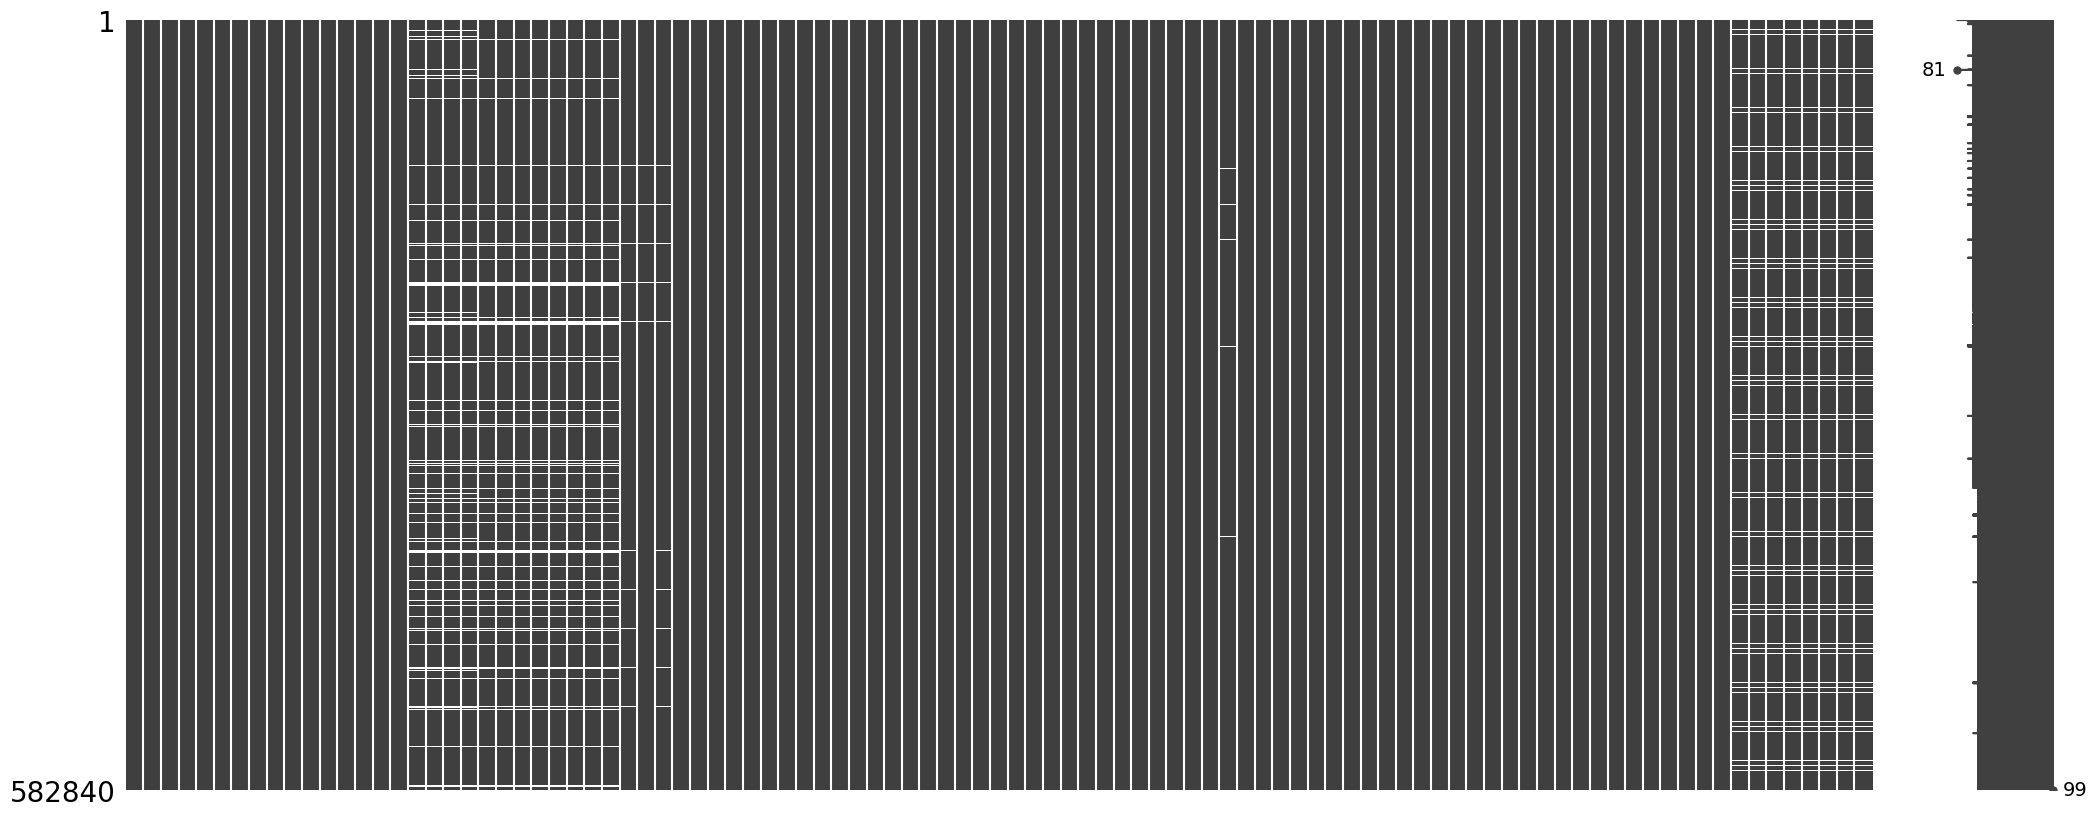

In [90]:
missingno.matrix(dataset)

In [91]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [92]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [93]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [94]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [95]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

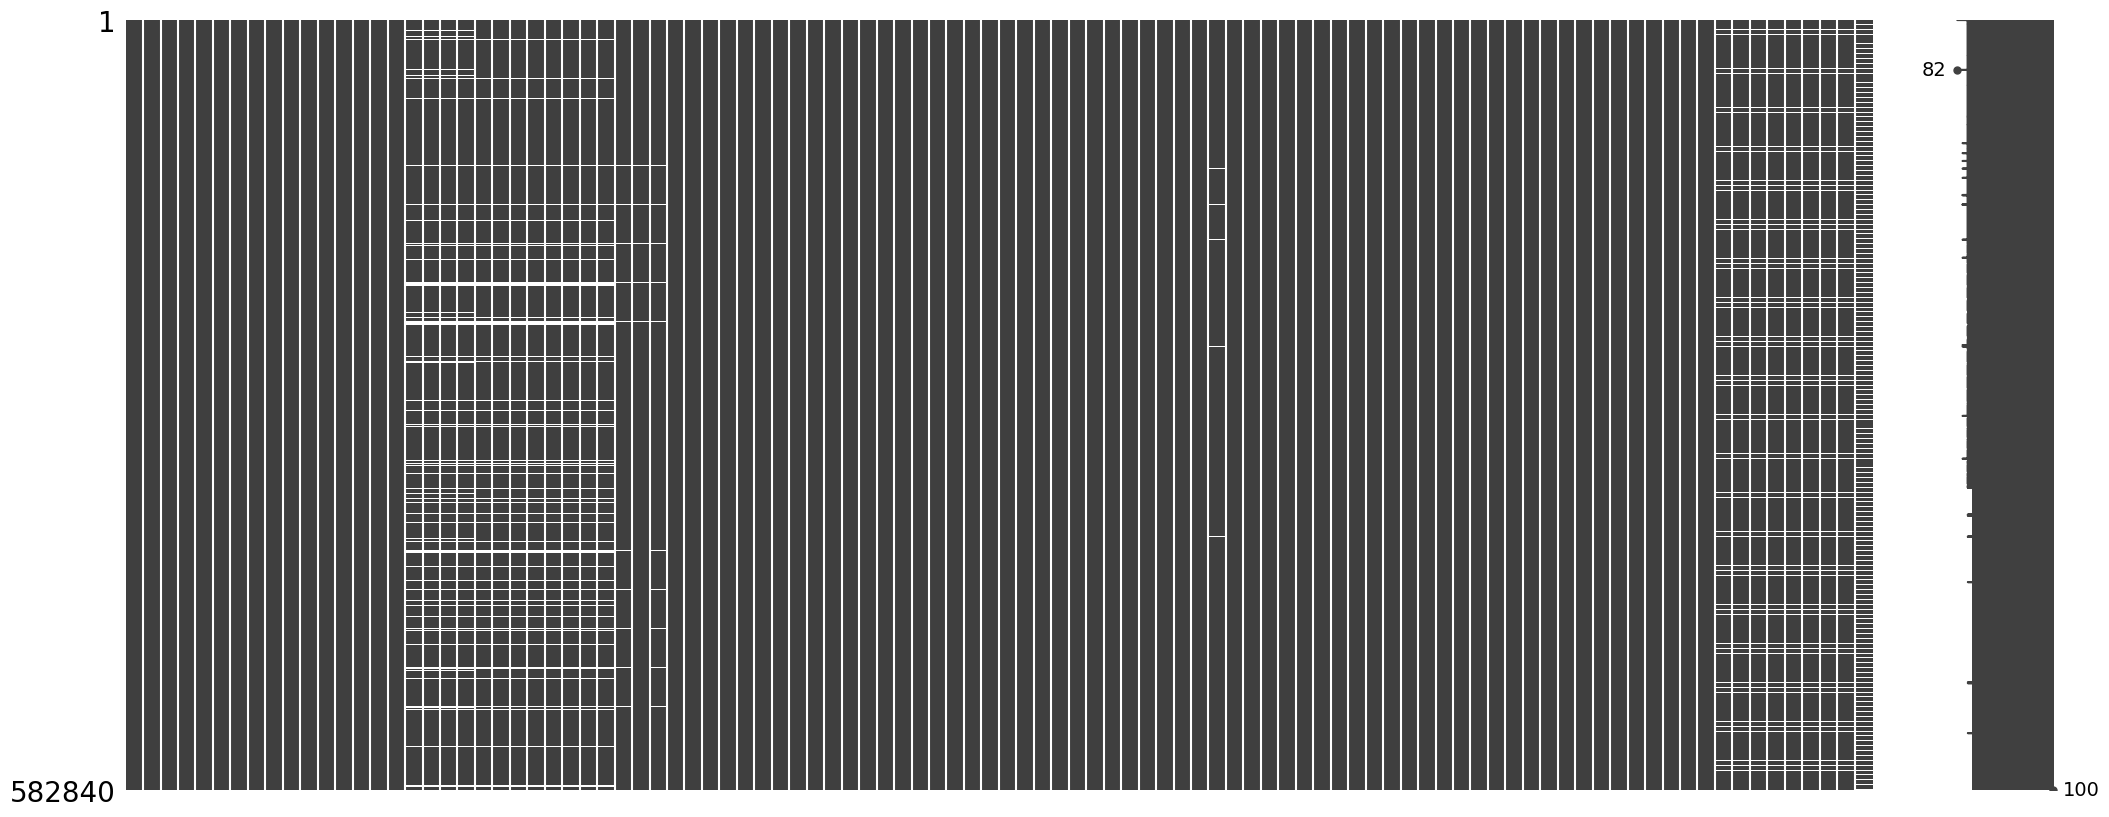

In [96]:
missingno.matrix(dataset)

In [97]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [98]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [99]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [100]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [101]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

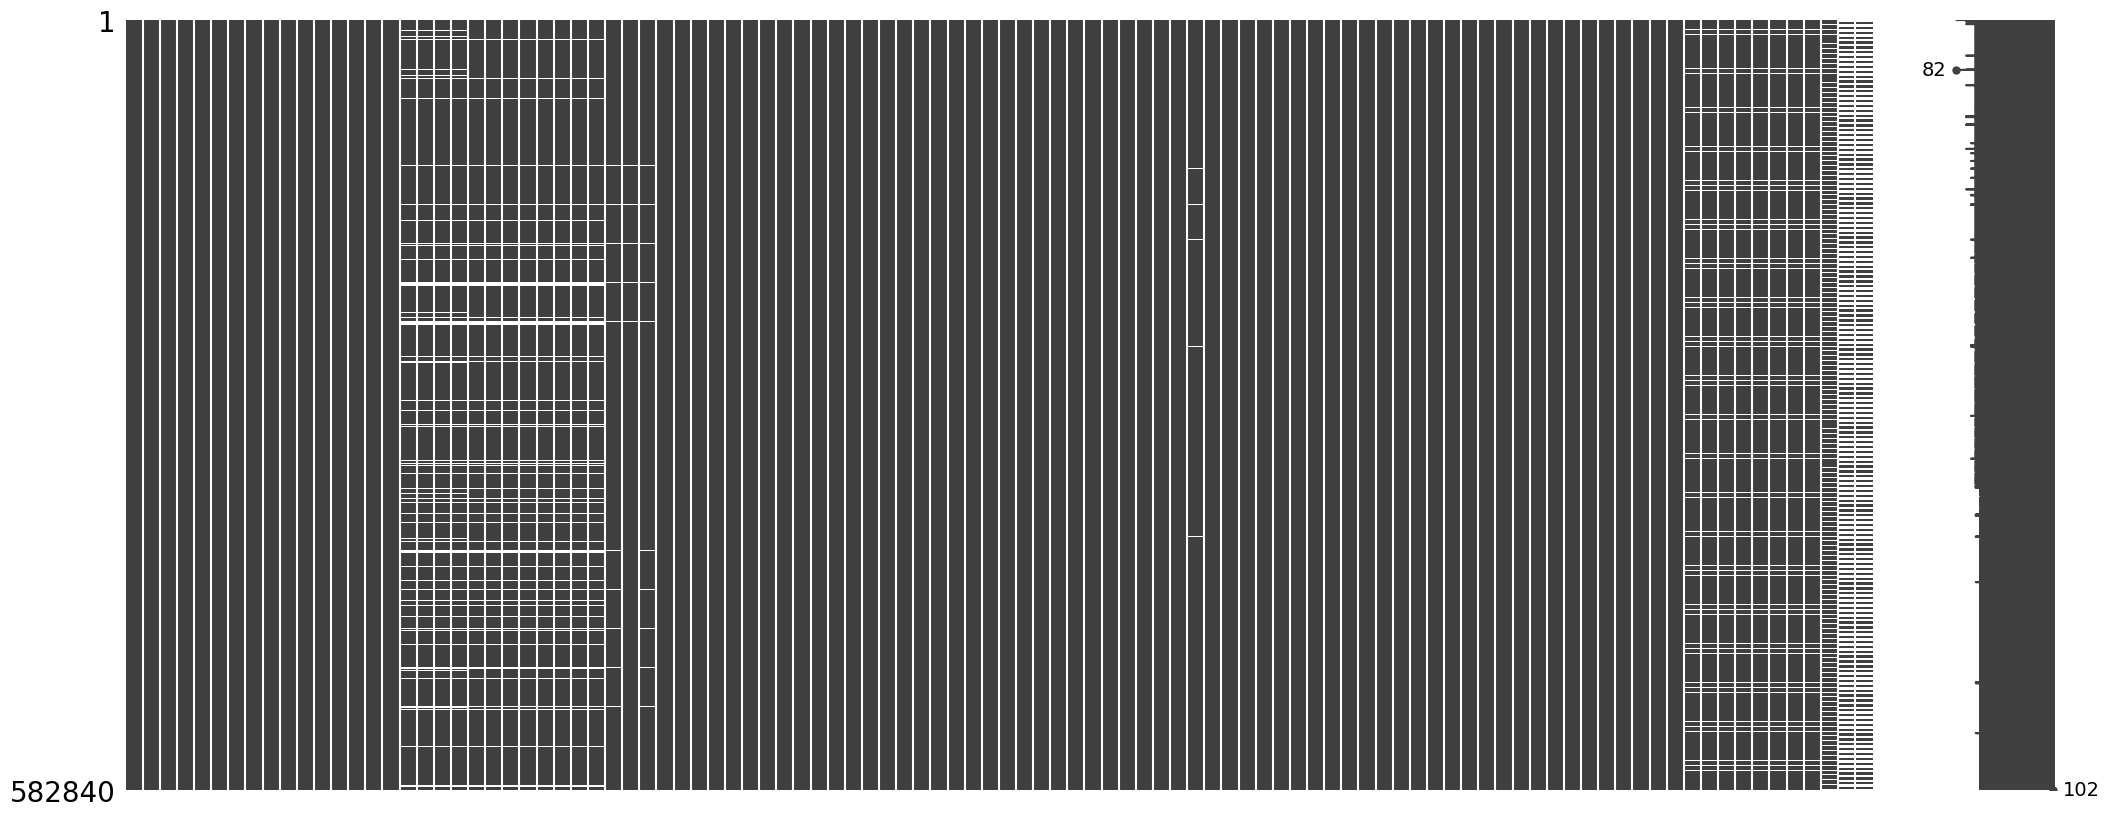

In [102]:
missingno.matrix(dataset)

In [103]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [104]:
missing

,Column,Missing
16,ndvi,7.417500
17,ndmi,7.417500
18,ndwi,7.417500
19,ndbi,7.417500
20,ndvi_mean,6.739900
21,ndmi_mean,6.739900
22,ndwi_mean,6.739900
23,ndbi_mean,6.739900
24,ndvi_std,6.739900
25,ndmi_std,6.739900


In [105]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,495.120838,-10.230000,-0.010000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,214.435127,-11.150000,2.090000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,3,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,310.555581,-32.810000,2.370000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,4,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745

In [106]:
dataset.reset_index(inplace=True, drop=True)

In [107]:
# dataset['cases'].value_counts()

In [108]:
# dataset['cases'].sum()

In [109]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,495.120838,-10.230000,-0.010000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,214.435127,-11.150000,2.090000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,3,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,310.555581,-32.810000,2.370000,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.000000,30,97,12,12,1,6,7,2,0,7.250000,21.500000,31.159420,1197.630236,37.000000,-32.000000,69.000000,3.000000,20.333333,20.833333,-8.166667,2843.000000,495.000000,56.000000,67.458711,1346.000000,223.000000,330.000000,1019.000000,17466.000000,77268.000000,28083.000000,122817.000000,17105.000000,74553.000000,35419.000000,127077.000000,3296.180000,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.155490,39.679430,2,3,3,2009,4,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745

In [110]:
cols = dataset.columns

In [111]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [112]:
len(cols)

102

In [113]:
years = dataset.year.unique().tolist()

In [114]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)